In [84]:
!pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------  2.1/2.1 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.6 MB/s eta 0:00:00


In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import pymysql as mysql
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import os 
import csv
import sqlite3
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score

In [3]:
from sqlalchemy import create_engine
db_username = 'root'
db_password = 'newpassword'
db_host = 'localhost'
db_port = '3306'
db_name = 'reviewsdb'
 

# Create a SQLAlchemy engine
engine = create_engine(f'mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/{db_name}')

# Read CSV file
df = pd.read_csv('Hotel_Reviews.csv')

# Push to SQL
df.to_sql('hotel_reviews', con=engine, if_exists='replace', index=False)

print("successfully loaded")

successfully loaded


In [4]:
engine = create_engine(f'mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/{db_name}')
query = "select * from hotel_reviews limit 5"
con = engine 
df =pd.read_sql(query, con)
from IPython.display import display
display(df)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [5]:

dbcon = mysql.connect(
    host = "localhost", 
    user="root", 
    password="newpassword", 
    db = "reviewsdb"
)
cursor = dbcon.cursor()
con = dbcon
df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 5", con)

from IPython.display import display
display(df)




C:\Users\DHAVID\AppData\Local\Temp\ipykernel_12936\310038930.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 5", con)


,Negative_Review,Positive_Review
0,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...
1,No Negative,No real complaints the hotel was great great ...
2,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...
3,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...
4,You When I booked with your company on line y...,Amazing location and building Romantic setting


In [10]:
engine = create_engine(f'mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/{db_name}')
# Load the data into a Pandas DataFrame
df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 10000", con)

# Drop duplicate rows (keep the first occurrence)
df.drop_duplicates(inplace=True)


# df.to_sql("hotelreviews", con, if_exists="replace", index=False)

print("Duplicates removed successfully!")




C:\Users\DHAVID\AppData\Local\Temp\ipykernel_12936\3620069861.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 10000", con)


Duplicates removed successfully!


In [55]:
df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 10000", con)
df['reviews'] = df['Negative_Review'] + ' ' + df['Positive_Review']

for index, row in df.iterrows():
    query = F"""
    update hotel_reviews
    set reviews = '{row['reviews']}
    where rewiews = none"""
display(df)


C:\Users\DHAVID\AppData\Local\Temp\ipykernel_12936\1700745382.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 10000", con)


,Negative_Review,Positive_Review,reviews
0,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...,I am so angry that i made this post available...
1,No Negative,No real complaints the hotel was great great ...,No Negative No real complaints the hotel was ...
2,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...,Rooms are nice but for elderly a bit difficul...
3,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...,My room was dirty and I was afraid to walk ba...
4,You When I booked with your company on line y...,Amazing location and building Romantic setting,You When I booked with your company on line y...
...,...,...,...
9995,No Negative,perfect staff,No Negative perfect staff
9996,Room size,The staff are really friendly,Room size The staff are really friendly
9997,Room very small Very cramped,Friendly,Room very small Very cramped Friendly
9998,No Negative,Beds were extra comfy Staff very friendly and...,No Negative Beds were extra comfy Staff very ...


In [56]:
#df = pd.read_sql_query("SELECT reviews FROM hotel_reviews LIMIT 100000", con)
df['reviews']
display(df)

,Negative_Review,Positive_Review,reviews
0,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...,I am so angry that i made this post available...
1,No Negative,No real complaints the hotel was great great ...,No Negative No real complaints the hotel was ...
2,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...,Rooms are nice but for elderly a bit difficul...
3,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...,My room was dirty and I was afraid to walk ba...
4,You When I booked with your company on line y...,Amazing location and building Romantic setting,You When I booked with your company on line y...
...,...,...,...
9995,No Negative,perfect staff,No Negative perfect staff
9996,Room size,The staff are really friendly,Room size The staff are really friendly
9997,Room very small Very cramped,Friendly,Room very small Very cramped Friendly
9998,No Negative,Beds were extra comfy Staff very friendly and...,No Negative Beds were extra comfy Staff very ...


In [57]:
import pandas as pd

# Load the reviews again if needed
df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 10000", con)

# Remove placeholder text like 'No Negative' and 'No Positive'
df = df[(df['Negative_Review'] != 'No Negative') | (df['Positive_Review'] != 'No Positive')]

# Create two separate DataFrames for labeling
df_neg = df[['Negative_Review']].copy()
df_neg = df_neg[df_neg['Negative_Review'] != 'No Negative']
df_neg.columns = ['review']
df_neg['sentiment'] = 'negative'

df_pos = df[['Positive_Review']].copy()
df_pos = df_pos[df_pos['Positive_Review'] != 'No Positive']
df_pos.columns = ['review']
df_pos['sentiment'] = 'positive'

# Combine both into a new labeled dataset
df_labeled = pd.concat([df_neg, df_pos], ignore_index=True)

# Optional: shuffle the dataset
df_labeled = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)

# Now you can split into X and y
X = df_labeled['review']
y = df_labeled['sentiment']

# Display first few rows
display(df_labeled.head())


C:\Users\DHAVID\AppData\Local\Temp\ipykernel_12936\593813463.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT Negative_Review, Positive_Review FROM hotel_reviews LIMIT 10000", con)


,review,sentiment
0,The hotel is 5 minutes from tube station Exce...,positive
1,Very helpful staff at the front desk and our ...,positive
2,Clean modern good location,positive
3,Standard Room was no bigger than a closet stu...,negative
4,Excellent location friendly and helpful staff...,positive


In [60]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

#Download stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
#Define preprocessing function
def preprocess_text(text):
        text = text.lower()  # Convert to lowercase
        text = re.sub(r'\W', ' ', text)  # Remove special characters
        text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
        tokens = word_tokenize(text)  # Tokenize
        tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
        return ' '.join(tokens)
   # Lemmatize
        lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    
        return ' '.join(lemmatized)
# Apply preprocessing
df_labeled['cleaned_review'] = df_labeled['review'].apply(preprocess_text)


display(df_labeled[['review', 'cleaned_review']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DHAVID\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DHAVID\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DHAVID\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review,cleaned_review
0,The hotel is 5 minutes from tube station Exce...,hotel 5 minutes tube station excellent breakfast
1,Very helpful staff at the front desk and our ...,helpful staff front desk room spacious comfort...
2,Clean modern good location,clean modern good location
3,Standard Room was no bigger than a closet stu...,standard room bigger closet stuffy bathroom we...
4,Excellent location friendly and helpful staff...,excellent location friendly helpful staff stor...


In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
tfidf_vectorizer = TfidfVectorizer()  # i did not Limit features but you can use max feature = 5000 to limit the feature if the data set is to large

# Transform text data into numerical form
X = tfidf_vectorizer.fit_transform(df_labeled['cleaned_review'])
y = df_labeled['sentiment']
# Convert to DataFrame for easy handling though my x and y are alraedy a data frame
# X_df = pd.DataFrame(X.toarray(), columns=tfidf_vectorizer.get_feature_names_out()) 
print("Done")


Done


In [62]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 190037 stored elements and shape (17021, 10836)>
  Coords	Values
  (0, 4937)	0.2765930592165229
  (0, 6257)	0.5361536043072956
  (0, 10017)	0.45268653891734856
  (0, 9190)	0.43937312329099715
  (0, 3740)	0.37859622151595823
  (0, 1601)	0.30777694723277554
  (1, 4814)	0.31479075040264914
  (1, 9137)	0.2174816311323427
  (1, 4317)	0.48652713454254315
  (1, 3027)	0.49617949882367957
  (1, 8254)	0.1931059017342264
  (1, 9011)	0.47008528522941095
  (1, 2283)	0.3353143468568738
  (2, 2126)	0.48041394183613667
  (2, 6318)	0.6984706639315241
  (2, 4519)	0.4116276148309554
  (2, 5819)	0.3345203772942686
  (3, 9137)	0.08802326793858772
  (3, 8254)	0.2344723888685224
  (3, 9164)	0.2105268104901168
  (3, 1420)	0.22390962894550398
  (3, 2187)	0.27794207641449864
  (3, 9331)	0.291446245220154
  (3, 1268)	0.13868879178684912
  (3, 10617)	0.23763076841297776
  :	:
  (17018, 8679)	0.24287136818729554
  (17018, 4488)	0.35727635758414067
  (17

In [63]:
from sklearn.model_selection import train_test_split

# Assuming you have a 'Sentiment' column with 0 (negative) and 1 (positive) labels
# y = df["reviews"] # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('done')

done


In [64]:

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Support Vector Machine (Linear)
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)


models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}
print("ready")

ready


In [65]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*50 + "\n")



--- Naive Bayes ---
Accuracy: 0.9095447870778267
Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.88      0.90      1600
    positive       0.89      0.94      0.92      1805

    accuracy                           0.91      3405
   macro avg       0.91      0.91      0.91      3405
weighted avg       0.91      0.91      0.91      3405



--- Logistic Regression ---
Accuracy: 0.925697503671072
Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.94      0.92      1600
    positive       0.94      0.92      0.93      1805

    accuracy                           0.93      3405
   macro avg       0.93      0.93      0.93      3405
weighted avg       0.93      0.93      0.93      3405



--- SVM ---
Accuracy: 0.9148311306901615
Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.91      0.91      1600
    positive      

In [66]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")


Naive Bayes Cross-Validation Accuracy: 0.9095 (+/- 0.0052)
Logistic Regression Cross-Validation Accuracy: 0.9202 (+/- 0.0041)
SVM Cross-Validation Accuracy: 0.9141 (+/- 0.0057)


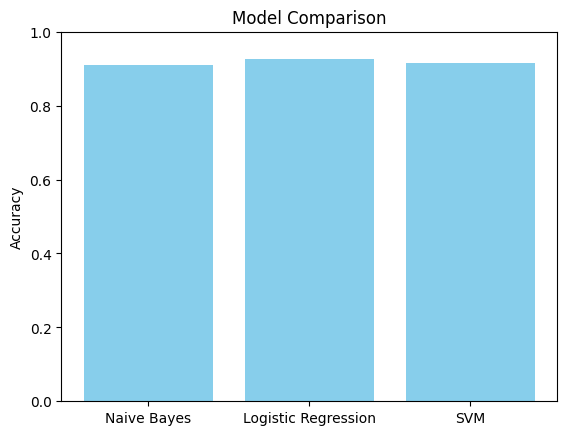

In [67]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Example of plotting results
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()


In [71]:
#hand written reviews

custom_reviews = [
    "I had a wonderful stay, the staff were incredibly kind and helpful.",          # Positive
    "Everything was dirty and the room smelled awful.",                            # Negative
    "The view from the balcony was breathtaking and peaceful.",                    # Positive
    "I waited over an hour to check in — totally unacceptable.",                   # Negative
    "Loved the breakfast and how quiet the place was!",                            # Positive
    "The air conditioning didn’t work and no one came to fix it.",                 # Negative
    "Such a beautiful hotel, I will definitely come back!",                        # Positive
    "The bed was uncomfortable and the bathroom had mold.",                        # Negative
    "Staff went above and beyond to make our anniversary special.",                # Positive
    "Terrible experience. I left a day early because I couldn’t stand it."         # Negative
]
cleaned_custom_reviews = [preprocess_text(review) for review in custom_reviews]
X_custom = tfidf_vectorizer.transform(cleaned_custom_reviews)
print ("done")

done


In [72]:
# Example: using SVM
predictions = svm_model.predict(X_custom)

# Show predictions
for review, pred in zip(custom_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {pred}\n")


Review: I had a wonderful stay, the staff were incredibly kind and helpful.
Predicted Sentiment: positive

Review: Everything was dirty and the room smelled awful.
Predicted Sentiment: negative

Review: The view from the balcony was breathtaking and peaceful.
Predicted Sentiment: positive

Review: I waited over an hour to check in — totally unacceptable.
Predicted Sentiment: negative

Review: Loved the breakfast and how quiet the place was!
Predicted Sentiment: positive

Review: The air conditioning didn’t work and no one came to fix it.
Predicted Sentiment: negative

Review: Such a beautiful hotel, I will definitely come back!
Predicted Sentiment: positive

Review: The bed was uncomfortable and the bathroom had mold.
Predicted Sentiment: negative

Review: Staff went above and beyond to make our anniversary special.
Predicted Sentiment: positive

Review: Terrible experience. I left a day early because I couldn’t stand it.
Predicted Sentiment: negative



In [75]:

predictions = nb_model.predict(X_custom)

# Show predictions
for review, pred in zip(custom_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {pred}\n")


Review: I had a wonderful stay, the staff were incredibly kind and helpful.
Predicted Sentiment: positive

Review: Everything was dirty and the room smelled awful.
Predicted Sentiment: negative

Review: The view from the balcony was breathtaking and peaceful.
Predicted Sentiment: positive

Review: I waited over an hour to check in — totally unacceptable.
Predicted Sentiment: negative

Review: Loved the breakfast and how quiet the place was!
Predicted Sentiment: positive

Review: The air conditioning didn’t work and no one came to fix it.
Predicted Sentiment: negative

Review: Such a beautiful hotel, I will definitely come back!
Predicted Sentiment: positive

Review: The bed was uncomfortable and the bathroom had mold.
Predicted Sentiment: negative

Review: Staff went above and beyond to make our anniversary special.
Predicted Sentiment: positive

Review: Terrible experience. I left a day early because I couldn’t stand it.
Predicted Sentiment: negative



In [76]:
predictions = lr_model.predict(X_custom)

# Show predictions
for review, pred in zip(custom_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {pred}\n")


Review: I had a wonderful stay, the staff were incredibly kind and helpful.
Predicted Sentiment: positive

Review: Everything was dirty and the room smelled awful.
Predicted Sentiment: negative

Review: The view from the balcony was breathtaking and peaceful.
Predicted Sentiment: negative

Review: I waited over an hour to check in — totally unacceptable.
Predicted Sentiment: negative

Review: Loved the breakfast and how quiet the place was!
Predicted Sentiment: positive

Review: The air conditioning didn’t work and no one came to fix it.
Predicted Sentiment: negative

Review: Such a beautiful hotel, I will definitely come back!
Predicted Sentiment: positive

Review: The bed was uncomfortable and the bathroom had mold.
Predicted Sentiment: negative

Review: Staff went above and beyond to make our anniversary special.
Predicted Sentiment: positive

Review: Terrible experience. I left a day early because I couldn’t stand it.
Predicted Sentiment: negative



In [78]:
import os
import joblib

os.makedirs('saved_models', exist_ok=True)


joblib.dump(lr_model, 'saved_models/logistic_regression_model.pkl')
joblib.dump(nb_model, 'saved_models/naive_bayes_model.pkl')
joblib.dump(svm_model, 'saved_models/svm_model.pkl')
joblib.dump(tfidf_vectorizer, 'saved_models/vectorizer.pkl') 


['saved_models/vectorizer.pkl']